In [133]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import SimpleITK as sitk
import os
import pytomography
from pytomography.io.SPECT import dicom
from pytomography.projectors.SPECT import SPECTSystemMatrix
from pytomography.algorithms import OSEM
from pytomography.likelihoods import PoissonLogLikelihood
from pytomography.transforms.SPECT import SPECTAttenuationTransform, SPECTPSFTransform
from pytomography.utils import plot_utils, ESSEScatterModel
from pytomography.metadata.SPECT import SPECTObjectMeta, SPECTProjMeta
import json

In [134]:
current_dir = os.getcwd()
DATADIR = os.path.join(current_dir, '../../../src/pytomography/data/NIST_attenuation_data')
FILE_WATER = os.path.join(DATADIR, 'water.csv')

In [135]:
# import json
# import numpy as np
# import SimpleITK as sitk
# import torch
# import pytomography

# # 1. Chargement de l'image de labels (l'image 3D générée par Gate)
# path_labels = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/nema_voxelized.mhd'
# img_sitk = sitk.ReadImage(path_labels)
# labels_array = sitk.GetArrayFromImage(img_sitk)

# # 2. Définition des densités (extraites de ton fichier .db)
# # Unités : g/cm3
# material_densities = {
#     "IEC_PLASTIC": 1.18,
#     "G4_WATER": 1.0,
#     "G4_LUNG_ICRP": 1.04,
#     "G4_AIR": 0.00120479  # 1.20479 mg/cm3 -> g/cm3
# }


# # 3. Chargement du mapping Volume -> Label/Material
# path_volumes = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/nema_voxelized_volumes.json'
# with open(path_volumes, "r") as f:
#     volumes_mapping = json.load(f)

# # 4. Calcul du mu de l'eau à 208 keV (référence NIST)
# # mu_water_ref est en cm^-1
# mu_water_ref = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, 208.0)

# # 5. Création de la carte de mu
# mu_map = np.zeros_like(labels_array, dtype=np.float32)

# # On parcourt chaque volume défini pour assigner sa valeur de mu
# for vol_name, info in volumes_mapping.items():
#     label = info['label']
#     material = info['material']
    
#     # mu_local = (densité_matériau / densité_eau) * mu_eau_ref
#     # On approxime ici que (mu/rho) est similaire pour ces matériaux à 208 keV
#     # sinon on peut charger chaque matériau spécifiquement
#     density_ratio = material_densities[material] / material_densities["G4_WATER"]
#     mu_val = density_ratio * mu_water_ref
    
#     mu_map[labels_array == label] = mu_val

# # 6. Conversion en Tensor pour PyTomography
# attenuation_map = torch.tensor(mu_map).to(pytomography.device)

# print(f"Carte mu générée avec succès.")
# print(f"Valeur mu Eau : {mu_water_ref:.4f} cm^-1")
# print(f"Valeur mu Plastique : {mu_map.max():.4f} cm^-1")

In [136]:
# import matplotlib.pyplot as plt

# plt.figure(figsize=(6, 5))
# slice_idx = attenuation_map.shape[0] // 2
# plt.imshow(mu_map[slice_idx], cmap='hot')
# plt.colorbar(label='linear attenuation coefficient mu (cm^-1)')
# plt.title(f"Coupe centrale de la mu-map (z={slice_idx})")
# plt.axis('off')
# plt.show()

In [137]:
def plot_mhd(mhd_path, title="Mu-Map à 208 keV", pos=[None, None, None]):
    img = sitk.ReadImage(mhd_path)
    data = sitk.GetArrayFromImage(img)
    cz, cy, cx = [s // 2 for s in data.shape]
    if pos[0] is not None:
        cz = min(pos[0], data.shape[0] - 1)
    if pos[1] is not None:
        cy = min(pos[1], data.shape[1] - 1)
    if pos[2] is not None:
        cx = min(pos[2], data.shape[2] - 1)

    # --- Définition du référentiel commun ---
    # Pour du 208 keV : 0 (Air) à 0.16 (Plastique dense)
    v_min, v_max = 0.0, 0.16 

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title}\nSpacing: {img.GetSpacing()}", fontsize=14)

    views = [
        (data[cz, :, :], f"Axial (Z={cz})"),
        (data[:, cy, :], f"Coronal (Y={cy})"),
        (data[:, :, cx], f"Sagittal (X={cx})")
    ]

    for i, (slice_data, label) in enumerate(views):
        im = axes[i].imshow(slice_data, cmap='viridis', origin='lower', 
                            vmin=v_min, vmax=v_max) # <--- Échelle fixe
        axes[i].set_title(label)
        plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04, label="$\mu$ ($cm^{-1}$)")

    plt.tight_layout()
    plt.show()

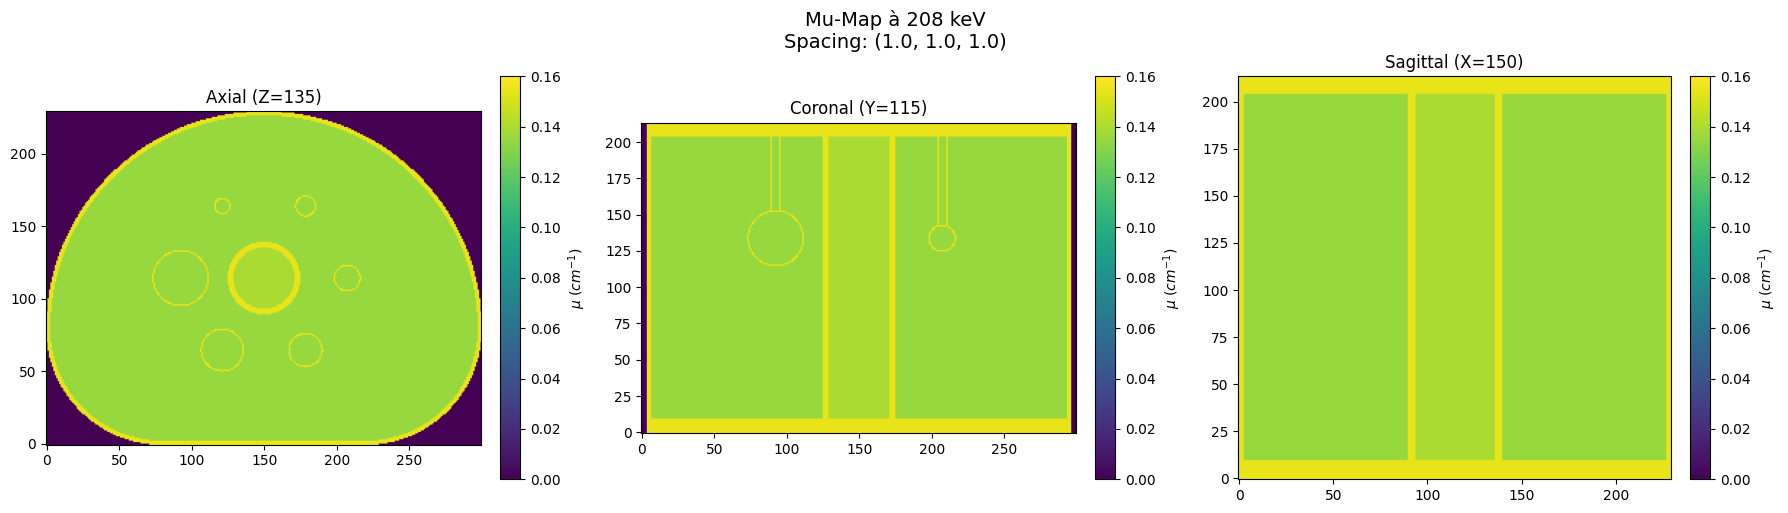

In [138]:
path_mu = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema_mu_map_208keV.mhd"
plot_mhd(path_mu, title="Mu-Map à 208 keV",pos=[135, None, None])

In [139]:
config = {
    "num_projections": 5,
    "pixel_size_cm": 0.44,
    "matrix_size": 128,
    "filenames": {
        "primary": "projections_primary.mhd",
        "scatter": "projections_scatter.mhd",
        "total": "projections_total.mhd"
    },
    "raws": {
        "primary": "projections_primary.raw",
        "scatter": "projections_scatter.raw",
        "total": "projections_total.raw"
    }
}

# path = '../../../../simulations-kernel-esse/validation_tests/output_spect_res_simu_we/'
path = '../../../../simulations-kernel-esse/validation_tests/output_spect/'

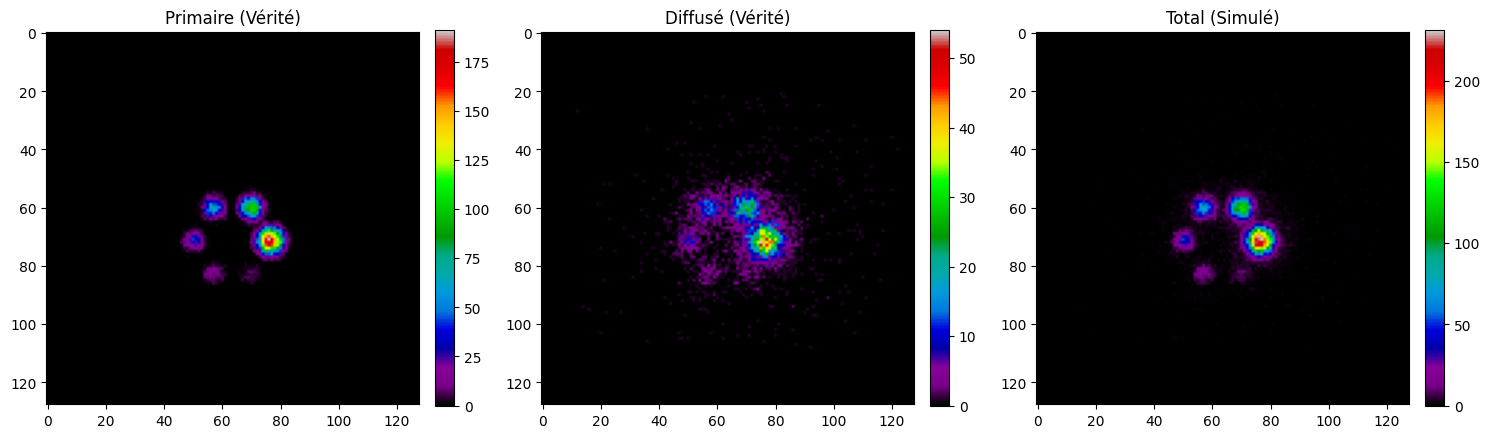

In [140]:
def load_gate_projection(filename):
    img = sitk.ReadImage(filename)
    data = sitk.GetArrayFromImage(img)
    return torch.tensor(data.astype(np.float32))

# Chargement des données
proj_primary = load_gate_projection(path + config["filenames"]["primary"])
proj_scatter = load_gate_projection(path + config["filenames"]["scatter"])
proj_total = load_gate_projection(path + config["filenames"]["total"])

# Affichage d'une projection (ex: angle 0)
angle_idx = 0
plt.figure(figsize=(15, 5))
titles = ['Primaire (Vérité)', 'Diffusé (Vérité)', 'Total (Simulé)']
projs = [proj_primary[angle_idx], proj_scatter[angle_idx], proj_total[angle_idx]]

for i, (p, t) in enumerate(zip(projs, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(t)
    plt.imshow(p.cpu(), cmap='nipy_spectral')
    plt.colorbar(fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [141]:
def check_raw_integrity(filepath, shape=(20, 128, 128)):
    if not os.path.exists(filepath):
        print(f"Fichier introuvable : {filepath}")
        return

    # Lecture du binaire brut (float32 car MET_FLOAT dans votre mhd)
    data = np.fromfile(filepath, dtype=np.float32)
    
    print(f"--- Analyse de {os.path.basename(filepath)} ---")
    print(f"Nombre total d'éléments : {data.size}")
    print(f"Somme totale des comptes : {data.sum()}")
    print(f"Valeur Max : {data.max()}")
    print(f"Valeur Min : {data.min()}")
    print(f"Nombre de pixels non nuls : {np.count_nonzero(data)}")
    

check_raw_integrity(os.path.join(path, config["raws"]["primary"]))
check_raw_integrity(os.path.join(path, config["raws"]["scatter"]))
check_raw_integrity(os.path.join(path, config["raws"]["total"]))

--- Analyse de projections_primary.raw ---
Nombre total d'éléments : 983040
Somme totale des comptes : 520878.0
Valeur Max : 223.0
Valeur Min : 0.0
Nombre de pixels non nuls : 32356
--- Analyse de projections_scatter.raw ---
Nombre total d'éléments : 983040
Somme totale des comptes : 291334.0
Valeur Max : 66.0
Valeur Min : 0.0
Nombre de pixels non nuls : 76710
--- Analyse de projections_total.raw ---
Nombre total d'éléments : 983040
Somme totale des comptes : 812212.0
Valeur Max : 274.0
Valeur Min : 0.0
Nombre de pixels non nuls : 79263


In [142]:


path = '../../../../simulations-kernel-esse/validation_tests/nema_final_sim/projections_nema_counts.raw'

check_raw_integrity(path)

Fichier introuvable : ../../../../simulations-kernel-esse/validation_tests/nema_final_sim/projections_nema_counts.raw


In [143]:
path = '/home/chloe/SPECT'  # Personal computer

# pathCT = os.path.join(path, 'Lu177-NEMA-SymT2', 'CT')
# files_CT = [os.path.join(pathCT, file) for file in os.listdir(pathCT)]

attenuation_map_path = "../../../../simulations-kernel-esse/validation_tests/nema_maps/nema_mu_map_208keV.mhd"

img = sitk.ReadImage(attenuation_map_path)
attenuation_map_np = sitk.GetArrayFromImage(img)
attenuation_map = torch.from_numpy(attenuation_map_np.astype(np.float32)).to(pytomography.device)



In [144]:
pytomography.device = 'cpu'
pytomography.dtype = torch.float32

energy = 208.0
nb_iter=10
nb_subset=8
index_peak = 0
photopeak_total = proj_total.to(pytomography.device)
photopeak_primary = proj_primary.to(pytomography.device)

In [145]:
# object_meta, proj_meta = dicom.get_metadata(file_NM)
projections = photopeak_total
projections_primary = photopeak_primary
# attenuation_map_total = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_total)
# attenuation_map_primary = dicom.get_attenuation_map_from_CT_slices(files_CT, photopeak_primary)

# attenuation_map_total = attenuation_map
# attenuation_map_primary = attenuation_map
mu_water = pytomography.utils.get_mu_from_spectrum_interp(FILE_WATER, energy)

In [146]:

collimator_name = 'SY-ME'               #todo: automatiser la récupération du collimateur à partir des métadonnées 
energy_kev = energy
intrinsic_resolution=0.35 # todo : à vérifier ??
psf_meta = dicom.get_psfmeta_from_scanner_params(
        collimator_name,
        energy_kev,
        intrinsic_resolution=intrinsic_resolution
)
psf_transform = SPECTPSFTransform(psf_meta)

with open("../../../../simulations-kernel-esse/validation_tests/output_spect/metadata_pytomography.json", "r") as f:
    meta_json = json.load(f)

# Instanciation automatique
proj_meta = SPECTProjMeta(
    projection_shape=(meta_json['simulation_params']['matrix_size'], 
                      meta_json['simulation_params']['matrix_size']),
    angles=np.array(meta_json['geometry']['angles']),
    radii=np.array(meta_json['geometry']['radii_cm']),
    dr=(meta_json['simulation_params']['pixel_size_cm'], 
        meta_json['simulation_params']['pixel_size_cm'])
)
# print(proj_meta.radii)

object_meta = SPECTObjectMeta(
    dr = (meta_json['simulation_params']['pixel_size_cm'], 
          meta_json['simulation_params']['pixel_size_cm'],
          meta_json['simulation_params']['pixel_size_cm']   
    ),
    shape= (meta_json['simulation_params']['matrix_size'], 
            meta_json['simulation_params']['matrix_size'],
            meta_json['simulation_params']['matrix_size']
    )
)

In [147]:
import torch.nn.functional as F

def resample_mu_map(mu_map, object_meta):
    """
    Redimensionne la Mu-Map 3D pour correspondre à la grille de reconstruction.
    """
    # mu_map est un tenseur (Z, Y, X)
    # F.interpolate attend (Batch, Channel, Z, Y, X)
    mu_tensor = mu_map.unsqueeze(0).unsqueeze(0)
    
    # On récupère la shape cible depuis object_meta
    target_shape = object_meta.shape # ex: (128, 128, 128)
    
    # Interpolation trilinéaire
    resampled = F.interpolate(
        mu_tensor, 
        size=target_shape, 
        mode='trilinear', 
        align_corners=False
    ).squeeze()
    
    return resampled

# --- Application ---

mu_aligned = resample_mu_map(attenuation_map, object_meta)
attenuation_map_total = mu_aligned
attenuation_map_primary = mu_aligned
att_transform_total = SPECTAttenuationTransform(attenuation_map=mu_aligned)
att_transform_primary = SPECTAttenuationTransform(attenuation_map=mu_aligned)

In [148]:
system_matrix_no_correction = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_correction = PoissonLogLikelihood(system_matrix_no_correction, photopeak_total)
algorithm_no_correction = OSEM(likelihood_no_correction)

In [149]:
recon_no_correction = algorithm_no_correction(n_iters=nb_iter, n_subsets=nb_subset)

In [150]:
system_matrix_no_scatter = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_primary, psf_transform],
    proj2proj_transforms=[],
    object_meta=object_meta,
    proj_meta=proj_meta
)

likelihood_no_scatter = PoissonLogLikelihood(system_matrix_no_scatter, photopeak_primary)
algorithm_no_scatter = OSEM(likelihood_no_scatter)

In [151]:
recon_no_scatter = algorithm_no_scatter(n_iters=nb_iter, n_subsets=nb_subset)

In [152]:
# index_peak, index_lower, index_upper = 1, 0, 2
# scatter_TEW = dicom.get_energy_window_scatter_estimate_projections(file_NM, projections, index_peak=index_peak, index_lower=index_lower, index_upper=index_upper, sigma_theta=2, sigma_r=0.48, sigma_z=0.48, proj_meta=proj_meta)

# system_matrix_TEW = SPECTSystemMatrix(
#         obj2obj_transforms = [att_transform_total, psf_transform],
#         proj2proj_transforms = [],
#         object_meta = object_meta,
#         proj_meta = proj_meta)

# likelihood_TEW = PoissonLogLikelihood(system_matrix_TEW, photopeak_total, scatter_TEW)
# algorithm_TEW = OSEM(likelihood_TEW)

In [153]:
npy_file = '../../../../simulations-kernel-esse/output/esse_kernels_3d.npy'
npy_file_amu = '../../../../simulations-kernel-esse/output/esse_amu_kernels_3d.npy'

from scipy.ndimage import gaussian_filter
def get_real_esse_kernels(npy_path, npy_path_amu, grid_size):

    Z_t, Y_t, X_t = grid_size

    # --- LOAD ---
    raw_k0 = np.load(npy_path)
    raw_amu = np.load(npy_path_amu)

    # raw_k0 = gaussian_filter(raw_k0, sigma=(1.5, 0, 1.5))
    # raw_amu = gaussian_filter(raw_amu, sigma=(1.5, 0, 1.5))

    # --- FORMAT ---
    if raw_k0.ndim == 3:
        k0 = np.transpose(raw_k0, (1, 2, 0))
        amu = np.transpose(raw_amu, (1, 2, 0))
    else:
        k0 = raw_k0
        amu = raw_amu

    # --- TAYLOR TERMS ---
    K0 = k0
    K1 = k0 * amu
    K2 = 0.5 * k0 * (amu ** 2)

    def pad_kernel(data):
        Z_s, Y_s, X_s = data.shape 

        pad_z = Z_t - Z_s
        pad_y = Y_t - Y_s
        pad_x = X_t - X_s

        paddings = (
            pad_x // 2, pad_x - (pad_x // 2), # Dim X
            pad_y // 2, pad_y - (pad_y // 2), # Dim Y
            pad_z // 2, pad_z - (pad_z // 2)  # Dim Z
        )

        tensor = torch.from_numpy(data).float()
        return torch.nn.functional.pad(tensor, paddings)

    # --- APPLY PADDING ---
    k0_t = pad_kernel(K0)
    k1_t = pad_kernel(K1)
    k2_t = pad_kernel(K2)

    # --- STACK FINAL ---
    final_kernels = torch.stack([
        k0_t,
        k1_t,
        k2_t
    ])

    return final_kernels

In [154]:
# Initilization

esse = ESSEScatterModel(
    object_meta=object_meta,
    attenuation_map=attenuation_map_total,
    energy=208.4,
    mu_water=mu_water,
    kernels=get_real_esse_kernels(
        npy_path=npy_file,
        npy_path_amu=npy_file_amu,
        grid_size=object_meta.padded_shape
    )
)

system_matrix_ESSE = SPECTSystemMatrix(
    obj2obj_transforms = [att_transform_total, psf_transform],
    proj2proj_transforms = [],
    object_meta = object_meta,
    proj_meta = proj_meta,
    scatter_model=esse
)

likelihood_ESSE = PoissonLogLikelihood(system_matrix_ESSE, photopeak_total)
algorithm_ESSE = OSEM(likelihood_ESSE)

In [155]:
recon_ESSE = algorithm_ESSE(n_iters=nb_iter, n_subsets=nb_subset)

In [156]:
def plot_comparative_spect(recon1, recon2, vmax, label1, label2, slice_idx=None):
    if slice_idx is None:
        slice_idx = recon1.shape[-1] // 2
    vmax = vmax if vmax is not None else max(recon1.max().item(), recon2.max().item())

    recon1_CPU = recon1.cpu().numpy() if hasattr(recon1, 'is_cuda') and recon1.is_cuda else (recon1.numpy() if hasattr(recon1, 'numpy') else recon1)
    recon2_CPU = recon2.cpu().numpy() if hasattr(recon2, 'is_cuda') and recon2.is_cuda else (recon2.numpy() if hasattr(recon2, 'numpy') else recon2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # RECONSTRUCTION 1
    im1 = axes[0].imshow(recon1_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    axes[0].set_title(f'{label1} ({nb_iter} iter, {nb_subset} subsets)')
    axes[0].axis('off')
    plt.colorbar(im1, ax=axes[0], label='Intensity')

    # RECONSTRUCTION 2
    im2 = axes[1].imshow(recon2_CPU[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    axes[1].set_title(f'{label2} ({nb_iter} iter, {nb_subset} subsets)')
    axes[1].axis('off')
    plt.colorbar(im2, ax=axes[1], label='Intensity')

    # DIFFÉRENCE
    diff = recon1_CPU - recon2_CPU
    im3 = axes[2].imshow(diff[:, :, slice_idx], cmap='RdBu_r', origin='lower', vmin=-vmax/2, vmax=vmax/2)
    axes[2].set_title(f'Différence ({label1} - {label2})')
    axes[2].axis('off')
    plt.colorbar(im3, ax=axes[2], label='Δ Intensity')

No correction reconstruction value range: [0.000, 30.000]


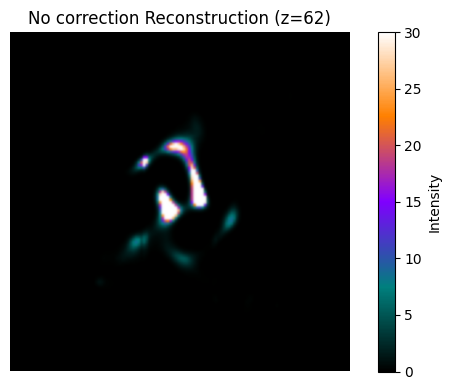

In [157]:
recon_max = recon_no_correction.max().item()
recon_min = recon_no_correction.min().item()
recon_max = 30
print(f"No correction reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 62

plt.figure(figsize=(6, 4))
plt.title(f'No correction Reconstruction (z={slice_idx})')
plt.imshow(recon_no_correction.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

No scatter reconstruction value range: [0.000, 30.000]


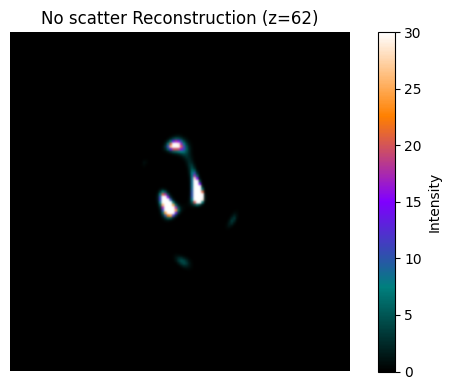

In [158]:
recon_max = recon_no_scatter.max().item()
recon_min = recon_no_scatter.min().item()
recon_max = 30
print(f"No scatter reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 62

plt.figure(figsize=(6, 4))
plt.title(f'No scatter Reconstruction (z={slice_idx})')
plt.imshow(recon_no_scatter.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

ESSE reconstruction value range: [0.000, 100.000]


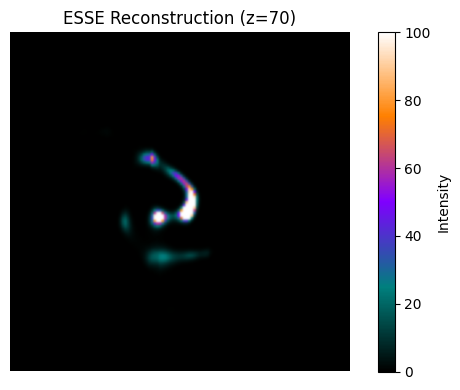

Sum of voxels in recon_no_correction: 8.67e+05
Sum of voxels in recon_no_scatter: 5.69e+05
Sum of voxels in recon_ESSE: 5.44e+05


In [169]:
recon_max = recon_ESSE.max().item()
recon_min = recon_ESSE.min().item()
recon_max = 100
print(f"ESSE reconstruction value range: [{recon_min:.3f}, {recon_max:.3f}]")

SPECT_imshow_kwargs = {
    'cmap': plot_utils.pet_cmap,
    'interpolation': 'Gaussian',
    'alpha': 1,
    'vmin': recon_min,
    'vmax': recon_max,
    'zorder': 1,
    'origin': 'lower'
}

slice_idx = 70

plt.figure(figsize=(6, 4))
plt.title(f'ESSE Reconstruction (z={slice_idx})')
plt.imshow(recon_ESSE.cpu()[:, :, slice_idx], **SPECT_imshow_kwargs)
plt.colorbar(label='Intensity')
plt.axis('off')

plt.tight_layout()
plt.show()

#print the sum of all voxels in the reconstructions
print(f"Sum of voxels in recon_no_correction: {recon_no_correction.sum().item():.2e}")
print(f"Sum of voxels in recon_no_scatter: {recon_no_scatter.sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE: {recon_ESSE.sum().item():.2e}")

In [160]:
slice_idx = 62
vmax = 100
print(f"Max value in recon_no_correction (z={slice_idx}): {recon_no_correction[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_no_scatter (z={slice_idx}): {recon_no_scatter[:, :, slice_idx].max().item():.3f}")
print(f"Max value in recon_ESSE (z={slice_idx}): {recon_ESSE[:, :, slice_idx].max().item():.3f}")

print(f"Sum of voxels in recon_no_correction (z={slice_idx}): {recon_no_correction[:, :, slice_idx].sum().item():.2e}")
print(f"Sum of voxels in recon_no_scatter (z={slice_idx}): {recon_no_scatter[:, :, slice_idx].sum().item():.2e}")
print(f"Sum of voxels in recon_ESSE (z={slice_idx}): {recon_ESSE[:, :, slice_idx].sum().item():.2e}")      

Max value in recon_no_correction (z=62): 675.259
Max value in recon_no_scatter (z=62): 670.557
Max value in recon_ESSE (z=62): 438.065
Sum of voxels in recon_no_correction (z=62): 1.62e+04
Sum of voxels in recon_no_scatter (z=62): 8.27e+03
Sum of voxels in recon_ESSE (z=62): 9.69e+03


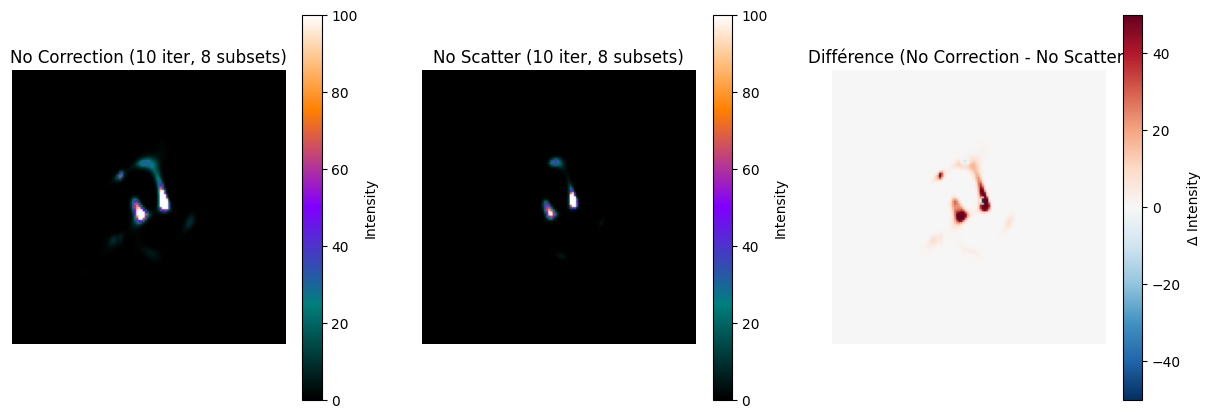

In [161]:
plot_comparative_spect(
    recon_no_correction, 
    recon_no_scatter, 
    vmax=vmax, 
    label1="No Correction", 
    label2="No Scatter", 
    slice_idx=slice_idx
)

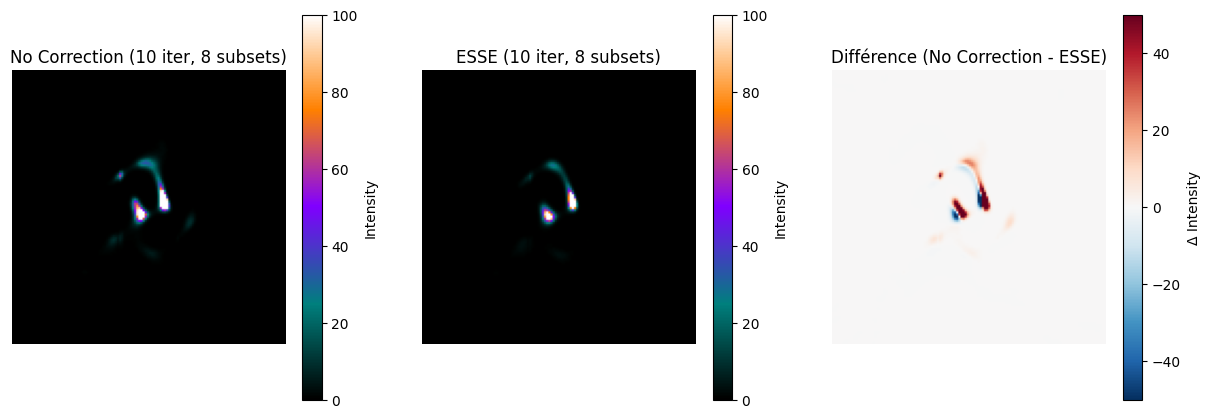

In [162]:
plot_comparative_spect(
    recon_no_correction, 
    recon_ESSE, 
    vmax=vmax, 
    label1="No Correction", 
    label2="ESSE", 
    slice_idx=slice_idx
    
)

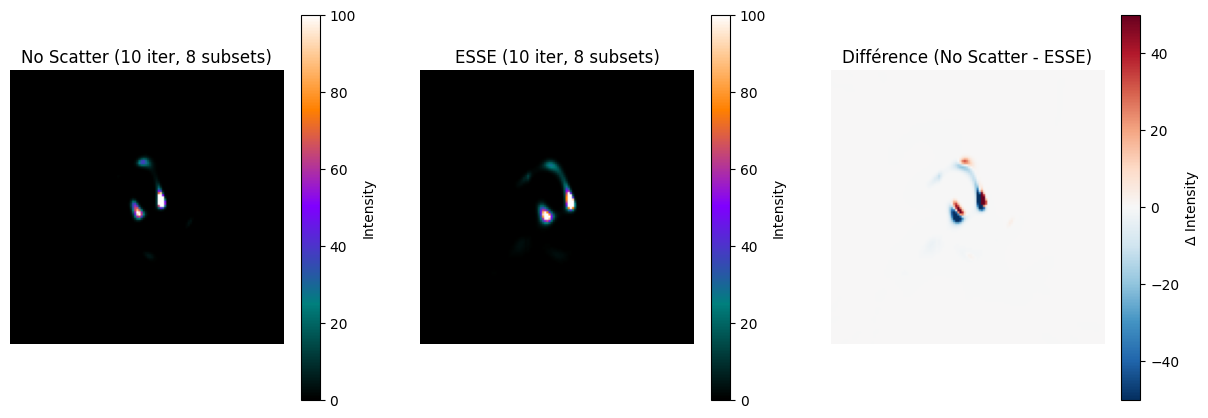

In [163]:
plot_comparative_spect(
    recon_no_scatter, 
    recon_ESSE, 
    vmax=vmax, 
    label1="No Scatter", 
    label2="ESSE", 
    slice_idx=slice_idx
)

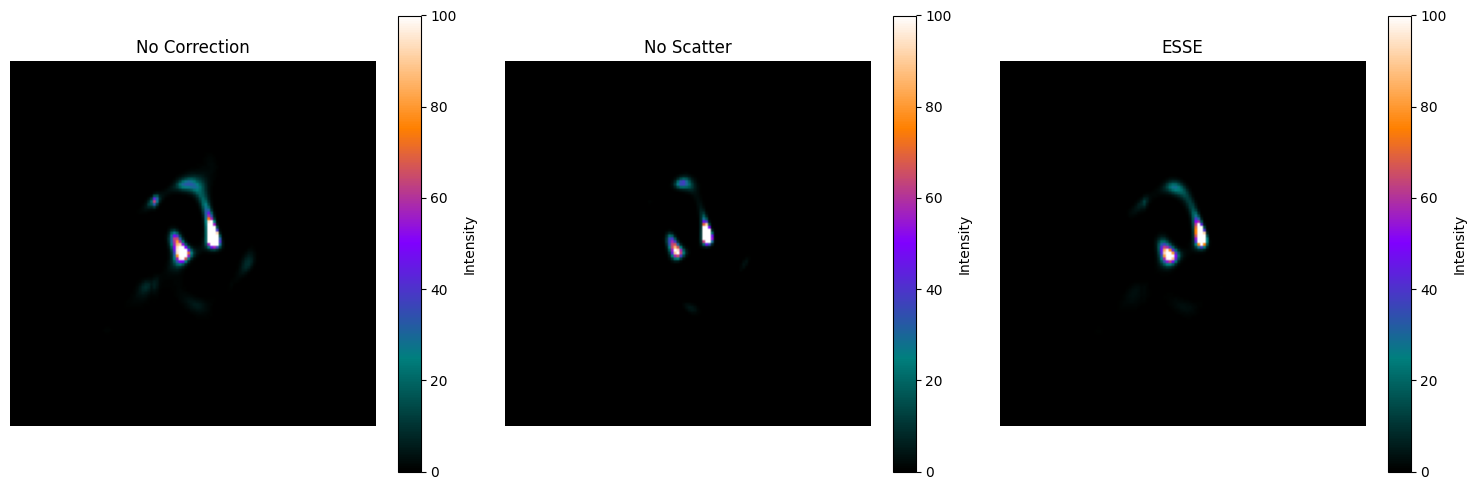

In [174]:
slice_idx = 62
vmax = 100
plt.figure(figsize=(15, 5))
titles = ['No Correction', 'No Scatter', 'ESSE']
recons = [recon_no_correction, recon_no_scatter, recon_ESSE]
for i, (rec, title) in enumerate(zip(recons, titles)):
    plt.subplot(1, 3, i+1)
    plt.title(title)
    plt.imshow(rec.cpu()[:, :, slice_idx], cmap=plot_utils.pet_cmap, vmin=0, vmax=vmax, origin='lower')
    plt.colorbar(label='Intensity')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [165]:
from skimage.metrics import mean_squared_error, normalized_root_mse, peak_signal_noise_ratio, structural_similarity
import pandas as pd

def get_stats(image_tensor, reference_tensor):
    # Passage en numpy CPU
    img = image_tensor.detach().cpu().numpy()
    ref = reference_tensor.detach().cpu().numpy()
    
    # Définition de la plage dynamique (essentielle pour PSNR et SSIM)
    data_range = ref.max() - ref.min()
    
    mse = mean_squared_error(ref, img)
    nrmse = normalized_root_mse(ref, img)
    psnr = peak_signal_noise_ratio(ref, img, data_range=data_range)
    # SSIM sur volume 3D (peut être lent selon la taille de la matrice)
    ssim = structural_similarity(ref, img, data_range=data_range)
    
    return [mse, nrmse, psnr, ssim]

# Calcul des métriques
metrics_no_corr = get_stats(recon_no_correction, recon_no_scatter)
metrics_esse = get_stats(recon_ESSE, recon_no_scatter)

# Présentation des résultats
df_stats = pd.DataFrame(
    [metrics_no_corr, metrics_esse],
    columns=['MSE (↓)', 'NRMSE (↓)', 'PSNR (↑)', 'SSIM (↑)'],
    index=['No Correction vs Reference', 'ESSE vs Reference']
)

print(df_stats.to_string())

                               MSE (↓)  NRMSE (↓)   PSNR (↑)  SSIM (↑)
No Correction vs Reference   26.004289   0.336219  62.588803  0.999574
ESSE vs Reference           126.824124   0.742506  55.707234  0.998967


In [166]:
# stats avec get_stats, seulement pour la coupe z=62
slice_idx = 62
print(f"Stats for No Correction vs Reference (z={slice_idx}):")
stats_no_corr_slice = get_stats(recon_no_correction[:, :, slice_idx], recon_no_scatter[:, :, slice_idx])
print(f"MSE: {stats_no_corr_slice[0]:.4f}, NRMSE: {stats_no_corr_slice[1]:.4f}, PSNR: {stats_no_corr_slice[2]:.2f} dB, SSIM: {stats_no_corr_slice[3]:.4f}")     
print(f"Stats for ESSE vs Reference (z={slice_idx}):")
stats_esse_slice = get_stats(recon_ESSE[:, :, slice_idx], recon_no_scatter[:, :, slice_idx])
print(f"MSE: {stats_esse_slice[0]:.4f}, NRMSE: {stats_esse_slice[1]:.4f}, PSNR: {stats_esse_slice[2]:.2f} dB, SSIM: {stats_esse_slice[3]:.4f}") 


Stats for No Correction vs Reference (z=62):
MSE: 32.2683, NRMSE: 0.4956, PSNR: 41.44 dB, SSIM: 0.9848
Stats for ESSE vs Reference (z=62):
MSE: 40.3445, NRMSE: 0.5542, PSNR: 40.47 dB, SSIM: 0.9883


In [167]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def get_sphere_mask(shape, center, radius_vox, pixel_size):
    """Génère un masque binaire pour une sphère."""
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    distance = np.sqrt((z - center[0])**2 + (y - center[1])**2 + (x - center[2])**2)
    return distance <= radius_vox

# --- Configuration des ROIs ---
pixel_size = 0.44  # cm (depuis votre config)
matrix_size = 128
center_vox = matrix_size // 2
# Rayon de placement des sphères (standard NEMA)
r_placement_cm = 5.72 
r_placement_vox = r_placement_cm / pixel_size

# Diamètres et angles (approximatifs, à ajuster selon nemaiec.py de Gate)
diameters_mm = [37, 28, 22, 17, 13, 10]
angles_deg = [0, 60, 120, 180, 240, 300]
z_slice = 62 # Votre slice d'intérêt

results = []
recons_dict = {
    "No Correction": recon_no_correction.cpu().numpy(),
    "No Scatter (Ref)": recon_no_scatter.cpu().numpy(),
    "ESSE": recon_ESSE.cpu().numpy()
}

# --- Calcul des statistiques ---
for d, angle in zip(diameters_mm, angles_deg):
    # Position de la sphère en voxels
    rad = np.radians(angle)
    # Note : Vérifiez l'inversion X/Y selon l'orientation de votre Mu-map
    x_s = center_vox + r_placement_vox * np.cos(rad)
    y_s = center_vox + r_placement_vox * np.sin(rad)
    
    mask = get_sphere_mask(recons_dict["ESSE"].shape, (z_slice, y_s, x_s), (d/20)/pixel_size, pixel_size)
    
    sphere_stats = {"diameter": d}
    for name, data in recons_dict.items():
        sphere_stats[f"{name}_mean"] = data[mask].mean()
        sphere_stats[f"{name}_std"] = data[mask].std()
    results.append(sphere_stats)

# --- ROI de Fond (Background) ---
# On prend une zone centrale ou loin des sphères
bg_mask = get_sphere_mask(recons_dict["ESSE"].shape, (z_slice, center_vox, center_vox), 2.0/pixel_size, pixel_size)
bg_stats = {name: {"mean": data[bg_mask].mean(), "std": data[bg_mask].std()} for name, data in recons_dict.items()}

In [168]:
# On suppose que la concentration réelle est celle de la référence "No Scatter" 
# ou une valeur théorique connue (ici on normalise par la moyenne de la Ref)
for res in results:
    true_val = res["No Scatter (Ref)_mean"]
    
    # Recovery Coefficient
    res["RC_NoCorr"] = res["No Correction_mean"] / true_val
    res["RC_ESSE"] = res["ESSE_mean"] / true_val
    
    # CNR
    res["CNR_NoCorr"] = (res["No Correction_mean"] - bg_stats["No Correction"]["mean"]) / bg_stats["No Correction"]["std"]
    res["CNR_ESSE"] = (res["ESSE_mean"] - bg_stats["ESSE"]["mean"]) / bg_stats["ESSE"]["std"]

# --- Affichage des résultats ---
import pandas as pd
df_final = pd.DataFrame(results)
print(df_final[["diameter", "RC_NoCorr", "RC_ESSE", "CNR_NoCorr", "CNR_ESSE"]])

   diameter     RC_NoCorr        RC_ESSE  CNR_NoCorr  CNR_ESSE
0        37     38.606281       3.650695   -0.545715 -0.445824
1        28   3414.006592      10.530480   -0.544837 -0.445830
2        22     82.512650      19.495594   -0.534485 -0.442109
3        17  12575.785156  152107.203125   -0.545793 -0.445834
4        13    143.779022     218.130219   -0.503182 -0.355703
5        10     19.821981       5.905214   -0.517881 -0.434241
